In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# First, define your training and testing data
# This is an example - replace with your actual data loading/preprocessing
# For example, you might load data from a CSV file or use a dataset from sklearn
# Example with random data:
x_train = np.random.random((1000, 10))  # 1000 samples, 10 features
y_train = np.random.randint(0, 2, (1000, 1))  # Binary labels (0 or 1)
x_test = np.random.random((200, 10))  # 200 test samples
y_test = np.random.randint(0, 2, (200, 1))  # Test labels

# Now build and train the model
ann_model = Sequential()

ann_model.add(Dense(16, input_dim=x_train.shape[1], activation='relu'))  # Now x_train is defined
ann_model.add(Dense(8, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy'])
ann_model.fit(x_train, y_train, epochs=20, batch_size=32)

ann_pred = (ann_model.predict(x_test) > 0.5)
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # Import the correct class

# Create the model with correct spelling
model = RandomForestClassifier()  # Fixed typo: RandomForestClassifier instead of RandomForestClassifer

# Note: parameter name should be 'cv' (lowercase) not 'CV'
search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=5)
search.fit(x_train, y_train)



Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5330 - loss: 0.6982
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5290 - loss: 0.6925
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5280 - loss: 0.6918
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5360 - loss: 0.6904
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5270 - loss: 0.6899
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5330 - loss: 0.6895
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5350 - loss: 0.6892
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5350 - loss: 0.6887
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5350 - loss: 0.6883
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5270 - loss: 0.6882
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5390 - loss: 0.6875
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5450 - lo

,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [3, 5, ...], 'max_features': [0.7, 0.8, ...], 'max_samples': [0.7, 0.8, ...], 'min_samples_split': [0.01, 0.03, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [13]:
plt.style.use("fivethirtyeight")

In [35]:
df = pd.read_csv("data_ecommerce_customer_churn.csv")

In [23]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [24]:
df.shape

(3941, 11)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [26]:
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='object')

In [29]:
df['Churn'].value_counts()

Churn
0    3267
1     674
Name: count, dtype: int64

In [32]:
for col in df.columns:
    if col not in ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','Complain','DaySinceLastOrder','CashbackAmount','Churn']:
        print(col,df[col].unique())
        print()
        

PreferedOrderCat ['Laptop & Accessory' 'Mobile' 'Fashion' 'Others' 'Mobile Phone' 'Grocery']

MaritalStatus ['Single' 'Married' 'Divorced']



In [33]:
df.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [34]:
for col in ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','Complain','DaySinceLastOrder','CashbackAmount','Churn']:
    print(col,len(df[df[col]==""]))
    print()

Tenure 0

WarehouseToHome 0

NumberOfDeviceRegistered 0

SatisfactionScore 0

NumberOfAddress 0

Complain 0

DaySinceLastOrder 0

CashbackAmount 0

Churn 0



In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [38]:
df['Churn'].value_counts()

Churn
0    3267
1     674
Name: count, dtype: int64

EDA PROCESS

In [39]:
df.shape

(3941, 11)

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,3747.0,10.081398,8.498864,0.0,2.0,9.00,16.00,61.00
WarehouseToHome,3772.0,15.650583,8.452301,5.0,9.0,14.00,21.00,127.00
NumberOfDeviceRegistered,3941.0,3.679269,1.013938,1.0,3.0,4.00,4.00,6.00
SatisfactionScore,3941.0,3.088302,1.381832,1.0,2.0,3.00,4.00,5.00
NumberOfAddress,3941.0,4.237757,2.626699,1.0,2.0,3.00,6.00,22.00
Complain,3941.0,0.282416,0.450232,0.0,0.0,0.00,1.00,1.00
DaySinceLastOrder,3728.0,4.531652,3.667648,0.0,2.0,3.00,7.00,46.00
CashbackAmount,3941.0,176.707419,48.791784,0.0,145.7,163.34,195.25,324.99
Churn,3941.0,0.171023,0.376576,0.0,0.0,0.00,0.00,1.00


In [72]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(18,4))
    plt.subplot(1,2,2)
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distribution of {column_name}")


    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean,color = "blue",linestyle ="-",label = "mean")
    plt.axvline(col_median,color = "pink",linestyle ="-",label = "median")

    plt.legend()

    plt.subplot(1,8,2)
    sns.boxplot(y = df[column_name])
    plt.title(f"Boxplot of{column_name}")
    plt.show()

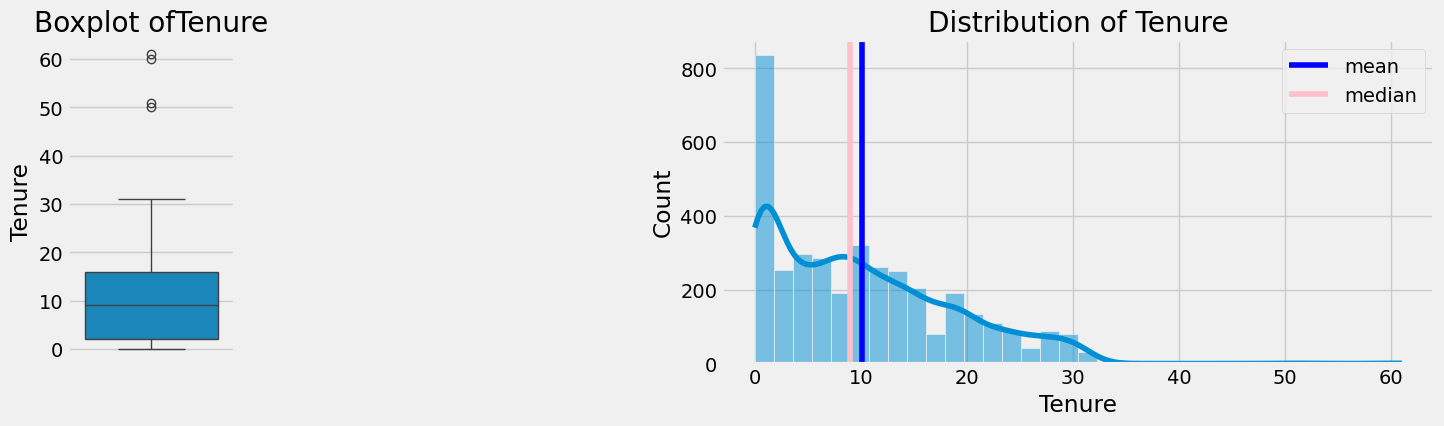

In [73]:
plot_distribution(df,"Tenure")

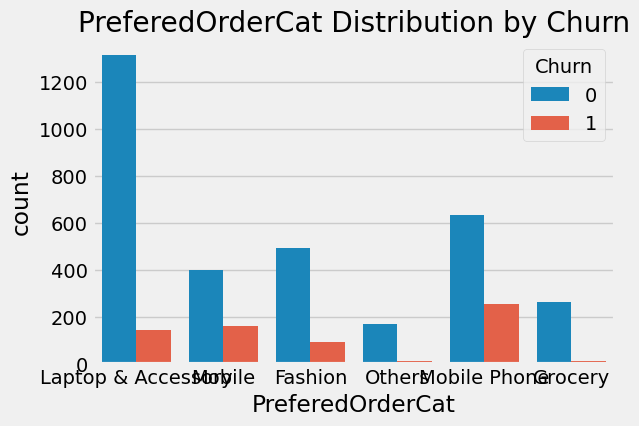

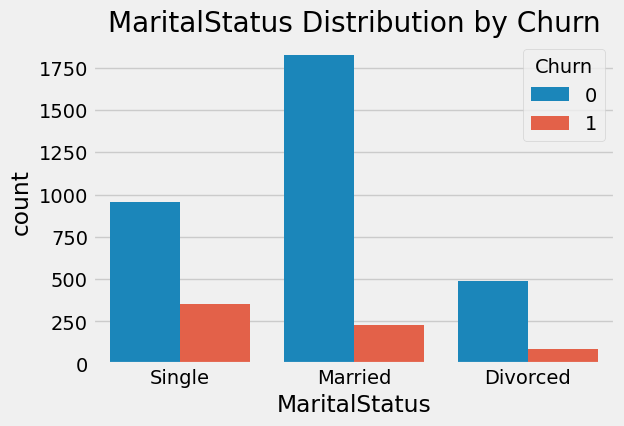

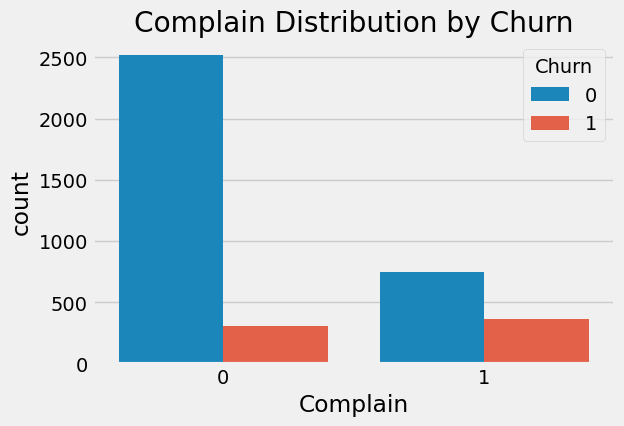

In [81]:
categorical_cols = df.select_dtypes(include = "object").columns.to_list()+['Complain']

for col in categorical_cols:
    plt.figure(figsize = (6,4))
    sns.countplot(data = df, x = col,hue = 'Churn')
    plt.title(f"{col} Distribution by Churn")
    plt.show()

label encoder

In [82]:
df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [84]:
objects_columns = df.select_dtypes(include = "object").columns

In [37]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     2055
Single      1310
Divorced     576
Name: count, dtype: int64

In [85]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in objects_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column]= label_encoder

In [87]:
encoders

{'PreferedOrderCat': LabelEncoder(), 'MaritalStatus': LabelEncoder()}

In [88]:
import pickle
with open ("encoder.pk1","wb")as f:
    pickle.dump(encoders, f)

In [90]:
from sklearn.preprocessing import StandardScaler

In [91]:
numerical_cols = ['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','Complain','DaySinceLastOrder','CashbackAmount','Churn']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [93]:
df['Churn'].value_counts()

Churn
-0.454209    3267
 2.201631     674
Name: count, dtype: int64

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
def train_test_split_and_features(df_features):
    y = df_features["Churn"]
    x = df_features.drop('Churn',axis=1)
    x = pd.get_dummies(x,dtype = int)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
    print(x.head(5))
    print(x.columns)
    features = list(x.columns)
    return x_train, x_test, y_train, y_test, features

In [36]:
df_features= pd.read_csv("data_ecommerce_customer_churn.csv")
x_train, x_test, y_train, y_test, features = train_test_split_and_features(df_features)

   Tenure  WarehouseToHome  NumberOfDeviceRegistered  SatisfactionScore  \
0    15.0             29.0                         4                  3   
1     7.0             25.0                         4                  1   
2    27.0             13.0                         3                  1   
3    20.0             25.0                         4                  3   
4    30.0             15.0                         4                  4   

   NumberOfAddress  Complain  DaySinceLastOrder  CashbackAmount  \
0                2         0                7.0          143.32   
1                2         0                7.0          129.29   
2                5         0                7.0          168.54   
3                7         0                NaN          230.27   
4                8         0                8.0          322.17   

   PreferedOrderCat_Fashion  PreferedOrderCat_Grocery  \
0                         0                         0   
1                         0     

In [39]:
x_train.head(10).T

,2484,2910,2961,713,1509,2519,2288,1606,1385,361
Tenure,8.00,15.00,9.00,9.00,14.00,12.00,13.00,17.00,18.00,14.00
WarehouseToHome,24.00,15.00,32.00,9.00,19.00,15.00,NaN,15.00,34.00,15.00
NumberOfDeviceRegistered,3.00,4.00,4.00,4.00,4.00,3.00,3.00,4.00,4.00,4.00
SatisfactionScore,3.00,1.00,3.00,2.00,5.00,1.00,3.00,4.00,4.00,1.00
NumberOfAddress,2.00,9.00,3.00,5.00,4.00,3.00,3.00,6.00,2.00,5.00
Complain,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
DaySinceLastOrder,2.00,1.00,NaN,12.00,8.00,3.00,2.00,1.00,6.00,3.00
CashbackAmount,156.89,296.13,228.88,196.99,169.48,294.31,123.45,172.65,267.04,165.69
PreferedOrderCat_Fashion,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
PreferedOrderCat_Grocery,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


In [40]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth = 5,min_samples_split = 0.05, max_features = 0.8, max_samples = 0.8):
    svm_model = SVC(kernel='rbf')
    svm_model.fit(x_train, y_train)
    svm_pred = svm_model.predict(x_test)

    print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
ann_model = Sequential()

ann_model.add(Dense(16, input_dim = x_train.shape[1], activation = 'relu'))
ann_model.add(Dense(8, activation = 'relu'))
ann_model.add(Dense(1, activation = 'sigmoid'))

ann_model.compile(optimizer = 'adam', loss = 'binary_crossentropy',
                 metrics = ['accuracy'])
ann_model.fit(x_train, y_train, epochs = 20, batch_size = 32)

ann_pred = (ann_model.predict(x_test) > 0.5)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5110 - loss: 0.7050
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4790 - loss: 0.6971
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4880 - loss: 0.6949
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5030 - loss: 0.6921
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5170 - loss: 0.6910
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5250 - loss: 0.6897
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5350 - loss: 0.6886
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5420 - loss: 0.6873
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5390 - loss: 0.6869
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5500 - loss: 0.6863
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5510 - loss: 0.6852
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5480 - lo

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression  # or any other model
import pandas as pd

# Assuming X_train and y_train are your training data
# Define your parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Create the search object
model = LogisticRegression()
search = GridSearchCV(model, param_grid, cv=5)

# Fit the search object to your data
search.fit(x_train, y_train)  # Replace X_train, y_train with your actual data

# Now you can use the search object
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score', inplace=True, ascending=False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002950,0.002390,0.001277,0.000863,0.1,liblinear,"{'C': 0.1, 'solver': 'liblinear'}",0.540,0.500,0.535,0.520,0.465,0.512,0.027313,1
5,0.003652,0.000260,0.000816,0.000025,10.0,lbfgs,"{'C': 10, 'solver': 'lbfgs'}",0.525,0.490,0.540,0.510,0.440,0.501,0.034699,2
7,0.003608,0.000234,0.000824,0.000038,100.0,lbfgs,"{'C': 100, 'solver': 'lbfgs'}",0.525,0.490,0.540,0.510,0.440,0.501,0.034699,2
1,0.010507,0.013497,0.000895,0.000065,0.1,lbfgs,"{'C': 0.1, 'solver': 'lbfgs'}",0.515,0.500,0.540,0.505,0.435,0.499,0.034843,4
4,0.001745,0.000066,0.000844,0.000107,10.0,liblinear,"{'C': 10, 'solver': 'liblinear'}",0.520,0.490,0.530,0.515,0.440,0.499,0.032311,4
6,0.001604,0.000064,0.000779,0.000049,100.0,liblinear,"{'C': 100, 'solver': 'liblinear'}",0.520,0.490,0.530,0.515,0.440,0.499,0.032311,4
2,0.001661,0.000114,0.000872,0.000134,1.0,liblinear,"{'C': 1, 'solver': 'liblinear'}",0.520,0.485,0.530,0.515,0.445,0.499,0.030887,7
3,0.004432,0.000764,0.000883,0.000047,1.0,lbfgs,"{'C': 1, 'solver': 'lbfgs'}",0.520,0.490,0.530,0.510,0.440,0.498,0.031875,8


In [15]:
param_grid=[{'max_depth':[3,5,7,10],
             'min_samples_split':[0.01,0.03,0.07,0.1],
             'max_features':[0.7,0.8,0.9,1.0],
             'max_samples':[0.7,0.8,0.9,1.0]}]

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # Import the correct class

# Create the model with correct spelling
model = RandomForestClassifier()  # Fixed typo: RandomForestClassifier instead of RandomForestClassifer

# Note: parameter name should be 'cv' (lowercase) not 'CV'
search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=5)
search.fit(x_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.520 total time=   0.2s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.570 total time=   0.2s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.535 total time=   0.3s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.515 total time=   0.3s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.535 total time=   0.3s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.535 total time=   0.3s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.535 total time=   0.3s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.530 total time=   0.3s


,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [3, 5, ...], 'max_features': [0.7, 0.8, ...], 'max_samples': [0.7, 0.8, ...], 'min_samples_split': [0.01, 0.03, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [20]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace = True,ascending = False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
73,0.542765,0.021540,0.010244,0.000669,5,0.7,0.9,0.03,"{'max_depth': 5, 'max_features': 0.7, 'max_sam...",0.530,0.595,0.575,0.550,0.540,0.558,0.023791,1
173,0.643748,0.026386,0.008712,0.000880,7,0.9,1.0,0.03,"{'max_depth': 7, 'max_features': 0.9, 'max_sam...",0.525,0.590,0.540,0.560,0.540,0.551,0.022450,2
128,0.592053,0.015412,0.012075,0.002048,7,0.7,0.7,0.01,"{'max_depth': 7, 'max_features': 0.7, 'max_sam...",0.515,0.575,0.540,0.555,0.550,0.547,0.019647,3
105,0.552001,0.035071,0.009642,0.002201,5,0.9,0.9,0.03,"{'max_depth': 5, 'max_features': 0.9, 'max_sam...",0.505,0.600,0.570,0.525,0.530,0.546,0.034264,4
140,0.661510,0.063524,0.010820,0.001669,7,0.7,1.0,0.01,"{'max_depth': 7, 'max_features': 0.7, 'max_sam...",0.520,0.555,0.545,0.545,0.560,0.545,0.013784,5
113,0.566367,0.007712,0.009644,0.001108,5,1.0,0.7,0.03,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.535,0.530,0.570,0.555,0.535,0.545,0.015166,5
120,0.648457,0.010580,0.009445,0.001131,5,1.0,0.9,0.01,"{'max_depth': 5, 'max_features': 1.0, 'max_sam...",0.545,0.565,0.560,0.520,0.535,0.545,0.016432,5
4,0.346835,0.027532,0.010323,0.001888,3,0.7,0.8,0.01,"{'max_depth': 3, 'max_features': 0.7, 'max_sam...",0.520,0.580,0.560,0.540,0.520,0.544,0.023324,8
217,0.718956,0.013802,0.009817,0.001419,10,0.8,0.9,0.03,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.525,0.515,0.565,0.565,0.550,0.544,0.020591,9
146,0.569371,0.015979,0.010521,0.001672,7,0.8,0.7,0.07,"{'max_depth': 7, 'max_features': 0.8, 'max_sam...",0.525,0.575,0.535,0.565,0.515,0.543,0.023152,10


In [22]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_save.csv",index = False)

In [23]:
search.best_params_

{'max_depth': 5,
 'max_features': 0.7,
 'max_samples': 0.9,
 'min_samples_split': 0.03}

In [26]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=None, min_samples_split=2, max_features=None, max_samples=None):
    # Example implementation using RandomForestClassifier
    from sklearn.ensemble import RandomForestClassifier
    
    # Create and train the model with the specified parameters
    model = RandomForestClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        max_samples=max_samples
    )
    
    model.fit(x_train, y_train)
    
    # Evaluate the model
    train_score = model.score(x_train, y_train)
    test_score = model.score(x_test, y_test)
    
    print(f"Training accuracy: {train_score:.4f}")
    print(f"Testing accuracy: {test_score:.4f}")
    
    return model

# Now call the function
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=10, min_samples_split=0.01, max_features=0.7, max_samples=1.0)

Training accuracy: 0.9720
Testing accuracy: 0.4950


In [27]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test, max_depth=10, min_samples_split=0.01, max_features=0.7, max_samples= 1.0)

Training accuracy: 0.9730
Testing accuracy: 0.5100


In [40]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score  # Import the required metrics functions

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Note: The correct function is accuracy_score, not accuracy_report

print(conf_matrix_svm, class_report_svm, accuracy_svm)

[[  0 106]
 [  0  94]]               precision    recall  f1-score   support

           0       0.00      0.00      0.00       106
           1       0.47      1.00      0.64        94

    accuracy                           0.47       200
   macro avg       0.23      0.50      0.32       200
weighted avg       0.22      0.47      0.30       200
 0.47


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

# Create some sample data
# In a real scenario, you would load your own dataset
X = np.random.rand(100, 5)  # 100 samples, 5 features
y = np.random.randint(0, 2, 100)  # Binary target variable

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.75      0.27      0.40        11
           1       0.69      0.95      0.80        19

    accuracy                           0.70        30
   macro avg       0.72      0.61      0.60        30
weighted avg       0.71      0.70      0.65        30



In [12]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np




model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.50      0.69      0.58        13
           1       0.67      0.47      0.55        17

    accuracy                           0.57        30
   macro avg       0.58      0.58      0.57        30
weighted avg       0.59      0.57      0.56        30



In [15]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [21]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report


model = CatBoostClassifier(verbose=False)
model.fit(x_train, y_train,)

y_pred = model.predict(x_test)


print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.77      0.61        13
           1       0.70      0.41      0.52        17

    accuracy                           0.57        30
   macro avg       0.60      0.59      0.56        30
weighted avg       0.61      0.57      0.56        30



In [27]:
!pip install sns

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for sns: filename=sns-0.1-py3-none-any.whl size=2680 sha256=57ce0643893e6c9b6c8689d1d09331668fd1d9253f0162566bda5b19f89d6c36
  Stored in directory: c:\users\acer\appdata\local\pip\cache\wheels\9f\50\d5\edd5c69ce4120485def2ffb0000bb72c4acc65c475f30d3a5d
Successfully built sns


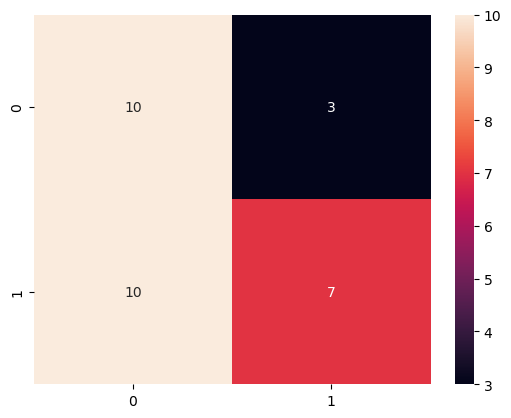

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

plt.show()

In [ ]:
# --- LOAD MODELS ---
# Ensure these files exist in the same folder as this script
with open('best_model.pkl', 'rb') as file:
    model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)


streamlit app code

In [36]:
import pandas as pd
df = pd.read_csv("data_ecommerce_customer_churn.csv")

In [38]:
df.head(1)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0


In [ ]:
import streamlit as st
import pickle
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

# Set streamlit layout to wide
st.set_page_config(layout="wide")

# --- LOAD MODELS ---
# Ensure these files exist in the same folder as this script
with open('best_model.pkl', 'rb') as file:
    model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    scaler = pickle.load(file)

# --- FEATURE DEFINITIONS ---
feature_names = [
    "Tenure", "WarehouseToHome", "NumberOfDeviceRegistered", "PreferedOrderCat",
    "SatisfactionScore", "MaritalStatus", "NumberOfAddress", "Complain",
    "DaySinceLastOrder", "CashbackAmount"
]

scale_vars = ["Tenure", "WarehouseToHome", "NumberOfDeviceRegistered", "SatisfactionScore", "NumberOfAddress"]

# Default values for the 10 features defined above
default_values = [72, 50, 10, 5, 2, 0, 0, 1, 1, 1] 

# --- SIDEBAR SETUP ---
st.sidebar.image("side.png",use_column_width=True)
st.sidebar.header("User Inputs")

user_inputs = {}
for i, feature in enumerate(feature_names):
    if feature in scale_vars:
        user_inputs[feature] = st.sidebar.number_input(
            feature, 
            value=float(default_values[i]), 
            step=0.1 if isinstance(default_values[i], float) else 1.0
        )
    elif isinstance(default_values[i], bool):
        user_inputs[feature] = st.sidebar.checkbox(feature, value=default_values[i])
    else:
        user_inputs[feature] = st.sidebar.number_input(feature, value=default_values[i], step=1)

# Convert input into dataframe
input_data = pd.DataFrame([user_inputs])

# Apply MinMaxScaler to required columns
input_data_scaled = input_data.copy()
input_data_scaled[scale_vars] = scaler.transform(input_data[scale_vars])

# --- APP LAYOUT ---
st.image("dataset-cover.png", use_column_width=True)
st.title("CUSTOMER CHURN PREDICTION")

left_col, right_col = st.columns(2)

# Left Column: Feature Importance
with left_col:
    st.header("Feature Importance")
    try:
        # Note: Ensure this CSV has exactly these column names
        feature_importance_df = pd.read_csv("data_ecommerce_customer_churn_importance.csv") 
        
        fig = px.bar(
            feature_importance_df.sort_values(by="Feature Importance Score", ascending=True),
            x="Feature Importance Score",
            y="Feature",
            orientation="h",
            title="Feature Importance",
            labels={"Feature Importance Score": "Importance", "Feature": "Features"},
            width=400,
            height=500
        )
        st.plotly_chart(fig)
    except Exception as e:
        st.error(f"Error loading importance data: {e}")

# Right Column: Prediction
with right_col:
    st.header("Prediction")
    if st.button("Predict"):
        # Corrected spelling: probabilities
        probabilities = model.predict_proba(input_data_scaled)[0]
        prediction = model.predict(input_data_scaled)[0]

        prediction_label = "CHURNED" if prediction == 1 else "RETAIN"

        st.subheader(f"Result: {prediction_label}")
        st.write(f"Churn Probability: {probabilities[1]:.2%}")
        st.write(f"Retention Probability: {probabilities[0]:.2%}")
        
        if prediction == 1:
            st.error("⚠️ This customer is likely to churn!")
        else:
            st.success("✅ This customer is likely to stay.")


# -m streamlit run churn_app_design.py
